# Demonstrating the Central Limit Theorem

## Theorem

The **Central Limit Theorem (CLT)** states that if we repeatedly draw random samples of size $n$ from any population with a finite mean $\mu$ and finite standard deviation $\sigma$, then the distribution of the sample means approaches a normal distribution as the sample size increases.

More precisely, for sufficiently large $n$,

$$
\bar{X} \sim N\left(\mu,\frac{\sigma}{\sqrt{n}}\right)
$$

where:

- $\bar{X}$ is the sample mean
- $\mu$ is the population mean
- $\sigma$ is the population standard deviation
- $\frac{\sigma}{\sqrt{n}}$ is the standard error of the mean

The theorem holds regardless of the shape of the original population distribution, provided the population has a finite mean and variance.


### What We Will Demonstrate

In this notebook, we will:

1. Create a highly non-normal population distribution.
2. Draw many random samples from that population.
3. Compute the mean of each sample.
4. Visualize the distribution of sample means for different sample sizes.
5. Observe how the sampling distribution becomes increasingly normal as the sample size grows.
6. Verify that:
   - The mean of the sampling distribution approaches the population mean.
   - The standard deviation of the sampling distribution approaches $\sigma/\sqrt{n}$.

In [2]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Create Population
Create a highly non-normal population distribution.

We will use a bi-modal distribution, as this is clearly not normal shaped and easy to create. 

It is important to note that in practise we normally are not able to observe the entire population like this and that is why we try to estimate its real parameters using statistical methods.

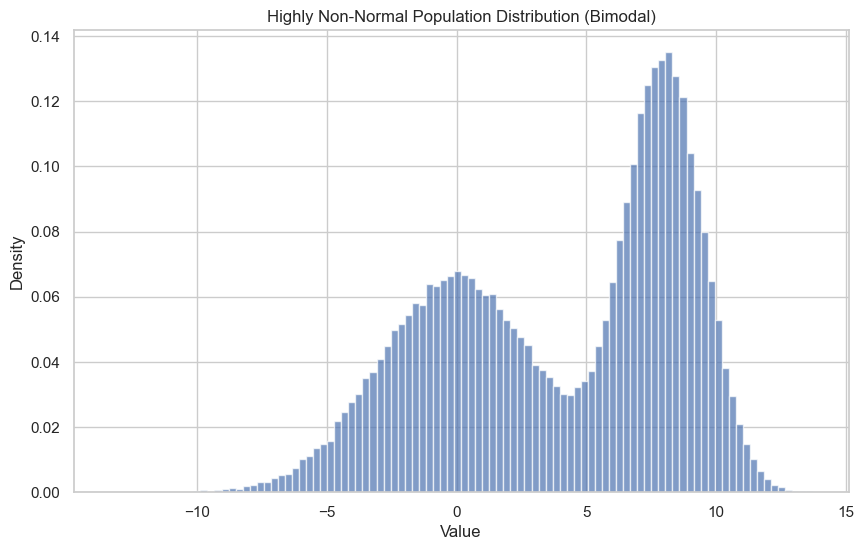

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Create a highly non-normal population (bimodal distribution)
n_population = 100_000

population = np.concatenate([
    np.random.normal(loc=0, scale=3, size=n_population // 2),   # centered at 0
    np.random.normal(loc=8, scale=1.5, size=n_population // 2)  # centered at 8
])

# Put into a pandas Series for convenience
population = pd.Series(population)

# Quick visualization
plt.hist(population, bins=100, density=True, alpha=0.7)
plt.title("Highly Non-Normal Population Distribution (Bimodal)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## Population Statistics

Before we start sampling, we compute the **true population mean and standard deviation** of our synthetic distribution.

These values will serve as the reference point when we later compare them to the sampling distribution of the mean.

In theory, the Central Limit Theorem predicts that:
- The mean of sample means will approach the population mean
- The spread of sample means will shrink with larger sample sizes

In [4]:
pop_mean = population.mean()
pop_std = population.std()

print(f"Population Mean: {pop_mean:.4f}")
print(f"Population Standard Deviation: {pop_std:.4f}")

Population Mean: 4.0011
Population Standard Deviation: 4.6529


## Repeated Sampling from the Population

To demonstrate the Central Limit Theorem, we will repeatedly draw random samples from our original population.

For each sample, we compute the **sample mean**. We then store only these sample means (not the raw samples themselves as we will not need them further).

This collection of sample means will form the **sampling distribution of the mean**.

In [5]:
# Parameters for the simulation
n_samples = 1000   # number of repeated samples
sample_size = 50   # size of each sample

# Store sample means
sample_means = []

# Sample means
sample_means = [
    population.sample(n=sample_size, replace=True).mean()
    for _ in range(n_samples)
]
# Store results in a DataFrame
sample_means_df = pd.DataFrame({"sample_mean": sample_means})

# Quick preview
sample_means_df.head()

,sample_mean
0,3.407247
1,3.206517
2,3.333292
3,4.482542
4,2.429866


## Statistics of the Sampling Distribution

Now that we have generated many sample means, we compute the **mean and standard deviation of the sampling distribution**.

These values are important for verifying the Central Limit Theorem:

- The mean of the sample means should be close to the **true population mean**
- The standard deviation of the sample means should be close to the **standard error**:

$$
\frac{\sigma}{\sqrt{n}}
$$

where:
- $\sigma$ is the population standard deviation  
- $n$ is the sample size  

This allows us to compare theory with simulation.
    

In [6]:
# Sampling distribution statistics
sampling_mean = sample_means_df["sample_mean"].mean()
sampling_std = sample_means_df["sample_mean"].std()

# Theoretical standard error
theoretical_se = pop_std / np.sqrt(sample_size)

# Nicely formatted output
print("Sampling Distribution Statistics")
print("-" * 35)
print(f"Mean of sample means: {sampling_mean:.4f}")
print(f"Population mean:      {pop_mean:.4f}")
print()
print(f"Std of sample means:  {sampling_std:.4f}")
print(f"Theoretical SE:       {theoretical_se:.4f}")

Sampling Distribution Statistics
-----------------------------------
Mean of sample means: 4.0149
Population mean:      4.0011

Std of sample means:  0.6634
Theoretical SE:       0.6580


## Visualizing the Sampling Distribution

Now we visualize the distribution of the sample means.

We expect that:
- The shape will become approximately normal, even though the original population is not.
- The distribution will be centered around the population mean.
- The spread will be smaller than the original population, depending on the sample size.

To make this clearer, we also overlay a theoretical normal distribution using the population mean and standard error.

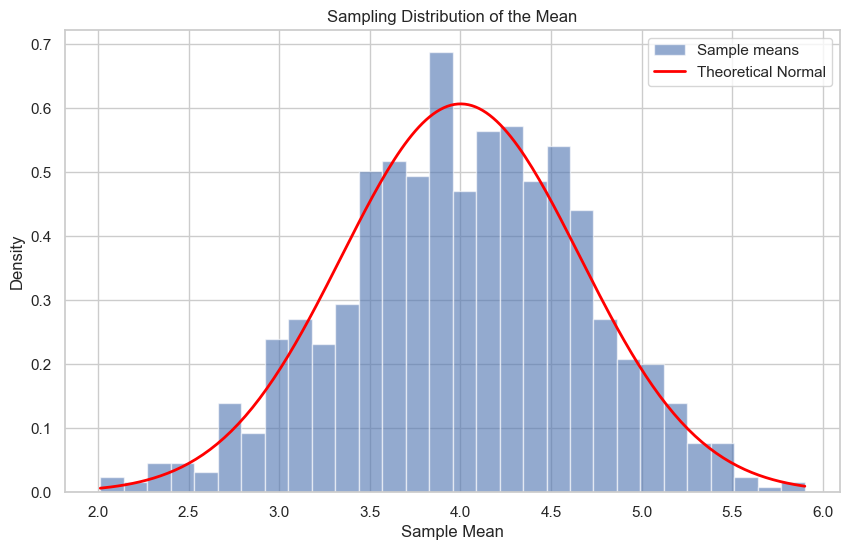

In [7]:
# Plot histogram of sample means
plt.hist(sample_means_df["sample_mean"], bins=30, density=True, alpha=0.6, label="Sample means")

# Overlay theoretical normal distribution
x = np.linspace(sample_means_df["sample_mean"].min(), sample_means_df["sample_mean"].max(), 200)
normal_curve = stats.norm.pdf(x, loc=pop_mean, scale=theoretical_se)

plt.plot(x, normal_curve, color="red", linewidth=2, label="Theoretical Normal")

# Labels and styling
plt.title("Sampling Distribution of the Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()

plt.show()

## Assessing Normality with a Q-Q Plot

The histogram suggests that the sampling distribution is approximately normal, but visual inspection of a histogram can sometimes be misleading.

A **Q-Q (quantile-quantile) plot** compares the quantiles of the observed sample means to the quantiles of a theoretical normal distribution.

If the sampling distribution is approximately normal, the points should lie close to a straight line. Systematic deviations from the line indicate departures from normality.

Text(0.5, 1.0, 'Q-Q Plot of Sample Means')

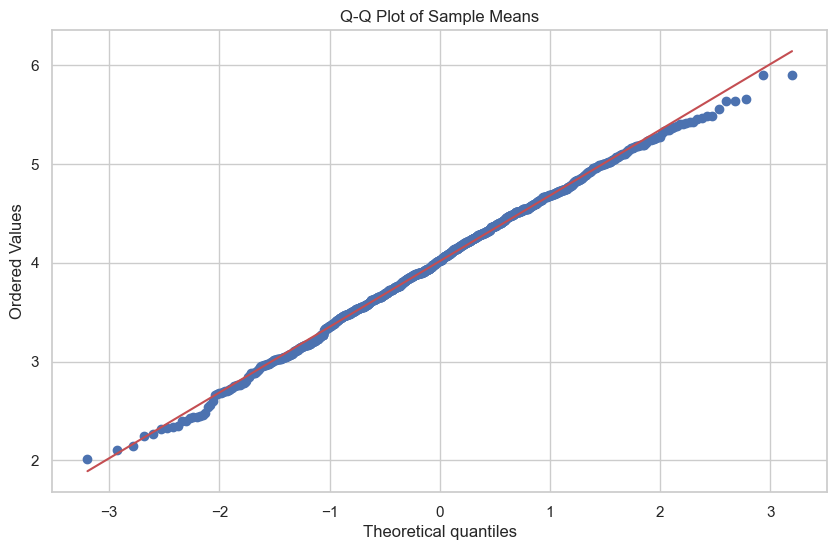

In [15]:
stats.probplot(sample_means_df["sample_mean"], dist="norm", plot=plt)

plt.title("Q-Q Plot of Sample Means")

## Increasing the Sample Size (n = 100)

Now we repeat the simulation with a larger sample size.

According to the Central Limit Theorem:
- The sampling distribution should become **narrower**
- The standard deviation (standard error) should decrease as:

$$
\frac{\sigma}{\sqrt{n}}
$$

So when we increase $n$ from 50 to 100, we expect the spread of sample means to shrink noticeably while staying centered at the same population mean.

We keep number of repeated samples unchanged at n_samples = 1000.

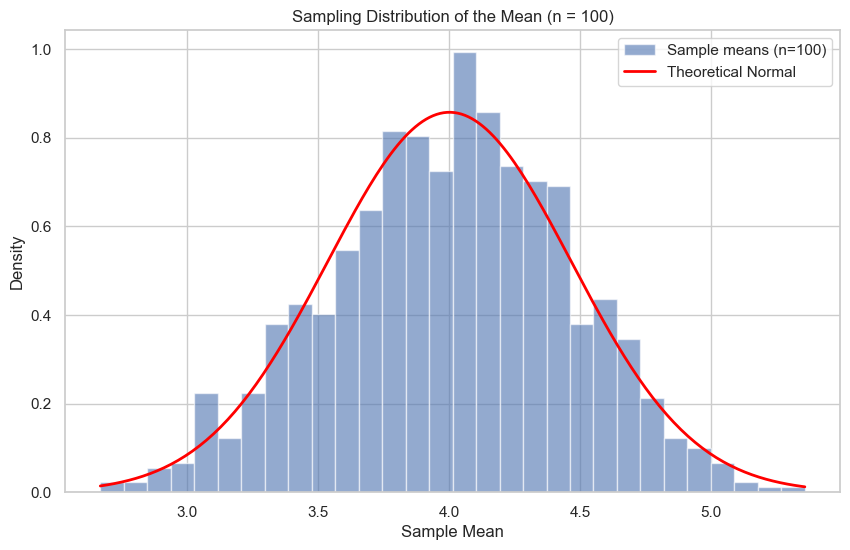

In [17]:
# Parameters
n_samples = 1000
sample_size_100 = 100

# Generate sample means for n = 100
sample_means_100 = [
    population.sample(n=sample_size_100, replace=True).mean()
    for _ in range(n_samples)
]

sample_means_df_100 = pd.DataFrame({"sample_mean": sample_means_100})

# Plot comparison
means_100 = sample_means_df_100["sample_mean"]

plt.hist(means_100, bins=30, density=True, alpha=0.6, label="Sample means (n=100)")

# Theoretical normal curve for n=100
x = np.linspace(means_100.min(), means_100.max(), 200)
normal_curve_100 = stats.norm.pdf(
    x,
    loc=pop_mean,
    scale=pop_std / np.sqrt(sample_size_100)
)

plt.plot(x, normal_curve_100, color="red", linewidth=2, label="Theoretical Normal")

plt.title("Sampling Distribution of the Mean (n = 100)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()

plt.show()

In [21]:
# Statistics for n = 100
sampling_mean_100 = sample_means_df_100["sample_mean"].mean()
sampling_std_100 = sample_means_df_100["sample_mean"].std()

# Theoretical standard error for n = 100
theoretical_se_100 = pop_std / np.sqrt(sample_size_100)

# Nicely formatted comparison
print("Sampling Distribution Statistics (n = 100)")
print("-" * 45)
print(f"Mean of sample means: {sampling_mean_100:.4f}")
print(f"Population mean:      {pop_mean:.4f}")
print()
print(f"Std of sample means:  {sampling_std_100:.4f}")
print(f"Theoretical SE:       {theoretical_se_100:.4f}")

Sampling Distribution Statistics (n = 100)
---------------------------------------------
Mean of sample means: 3.9885
Population mean:      4.0011

Std of sample means:  0.4772
Theoretical SE:       0.4653


Text(0.5, 1.0, 'Q-Q Plot of Sample Means with n=100')

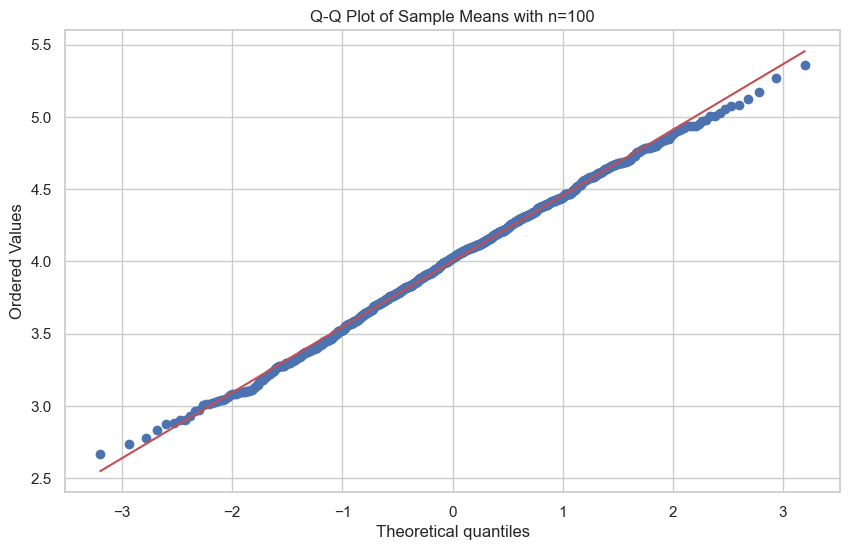

In [18]:
stats.probplot(sample_means_df_100["sample_mean"], dist="norm", plot=plt)

plt.title("Q-Q Plot of Sample Means with n=100")

## Confidence Interval from a Single Sample (n = 100)

Finally let us construct a confidence interval to estimate the population mean as if we had only **one sample of size 100** available to work with as in practice, we normally do not observe the full sampling distribution.

Using the Central Limit Theorem, we approximate the sampling distribution of the mean as normal and construct a 95% confidence interval:

$$
\bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}
$$

where:
- $\bar{x}$ is the sample mean  
- $s$ is the sample standard deviation  
- $n$ is the sample size  

This interval gives a range of plausible values for the true population mean.

In [22]:
# Take ONE sample of size 100
single_sample = population.sample(n=100, replace=True)

# Compute sample statistics
x_bar = single_sample.mean()
s = single_sample.std()
n = 100

# Standard error
se = s / np.sqrt(n)

# 95% confidence interval
ci_lower = x_bar - 1.96 * se
ci_upper = x_bar + 1.96 * se

# Print results
print("95% Confidence Interval from Single Sample (n = 100)")
print("-" * 55)
print(f"Sample Mean: {x_bar:.4f}")
print(f"Sample Std:  {s:.4f}")
print()
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"True Population Mean: {pop_mean:.4f}")

95% Confidence Interval from Single Sample (n = 100)
-------------------------------------------------------
Sample Mean: 3.8578
Sample Std:  5.0126

95% CI: [2.8754, 4.8403]
True Population Mean: 4.0011


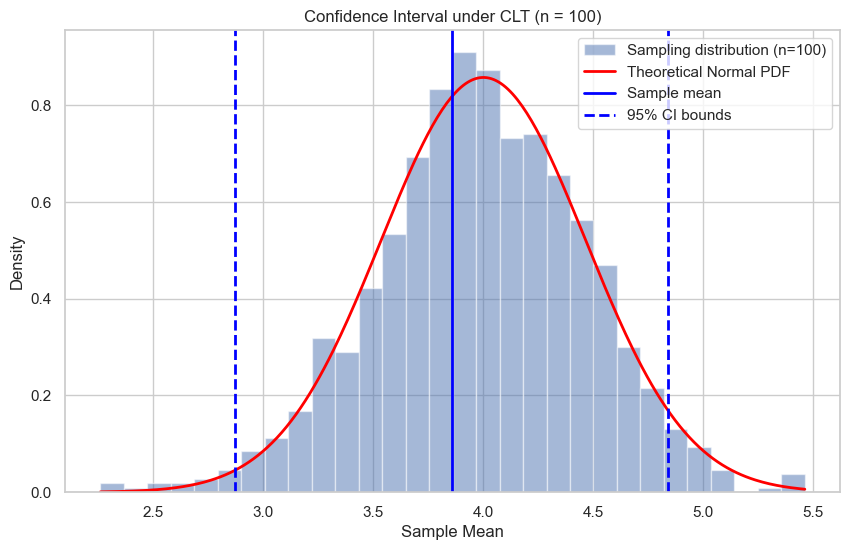

In [23]:

# ---- histogram ----
plt.hist(means_100, bins=30, density=True, alpha=0.5, label="Sampling distribution (n=100)")

# ---- theoretical normal curve ----
x = np.linspace(means_100.min(), means_100.max(), 300)
pdf = stats.norm.pdf(x, loc=pop_mean, scale=pop_std / np.sqrt(n))

plt.plot(x, pdf, color="red", linewidth=2, label="Theoretical Normal PDF")

# ---- vertical lines ----
plt.axvline(x_bar, color="blue", linewidth=2, label="Sample mean")
plt.axvline(ci_lower, color="blue", linestyle="--", linewidth=2, label="95% CI bounds")
plt.axvline(ci_upper, color="blue", linestyle="--", linewidth=2)

# ---- styling ----
plt.title("Confidence Interval under CLT (n = 100)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()


## Interpretation of the Confidence Interval

The 95% confidence interval we constructed from a single sample of size 100 is:

- an estimate of a range of plausible values for the true population mean.

A correct interpretation is:

> If we were to repeat this sampling process many times and construct a confidence interval each time, approximately 95% of those intervals would contain the true population mean.

Important clarifications:
- The population mean is fixed (it does not change).
- The confidence interval is random (it changes depending on the sample).
- For this single interval, we do not say there is a 95% probability that the true mean lies in the interval — it either does or does not, but only 5% of the times an interval constructed using this method from a random sample will fail to contain the true population parameter.

## Confidence Intervals for Proportions as a Special Case

Suppose each observation can take only two values (**Bernoulli random variable**):

- 1 = success
- 0 = failure

If the probability of success is $p$, then:

$$
E[X] = p
$$

and

$$
Var(X) = p(1-p)
$$

Notice that the sample mean of Bernoulli observations is exactly the sample proportion:

$$
\bar X = \hat p
$$

Therefore, the Central Limit Theorem applies directly:

$$
\hat p \approx N\left(
p,
\frac{p(1-p)}{n}
\right)
$$

for sufficiently large sample sizes.

The standard error of the sample proportion is therefore:

$$
SE(\hat p)
=
\sqrt{\frac{p(1-p)}{n}}
$$

Since the true proportion $p$ is unknown, we estimate it using the sample proportion $\hat p$:

$$
SE(\hat p)
\approx
\sqrt{\frac{\hat p(1-\hat p)}{n}}
$$

This gives the familiar 95% confidence interval for a population proportion:

$$
\hat p
\pm
1.96
\sqrt{\frac{\hat p(1-\hat p)}{n}}
$$

Thus, confidence intervals for proportions are simply a special case of confidence intervals for means, where the observations are restricted to the values 0 and 1.